In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

In [3]:
root_path = Path("..")

test_data_path = root_path / 'fine_tuning' / 'data' / 'datasets' / 'test_ds.csv'
fine_tuned_model_path = root_path / 'streamlit_app' / 'data' / 'fine_tuned_model'

In [4]:
test_df = pd.read_csv(test_data_path)

In [5]:
from sentence_transformers import SentenceTransformer
import torch

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = str(get_device())
print(f"Using device: {device}")

Using device: mps


In [6]:
base_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)
fine_tuned_model = SentenceTransformer(str(fine_tuned_model_path), device=device)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

You are trying to use a model that was created with Sentence Transformers version 5.3.0, but you're currently using version 5.2.2. This might cause unexpected behavior or errors. In that case, try to update to the latest version.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [7]:
from tqdm.autonotebook import trange

CHUNK_SIZE = 100

jittered_titles = test_df['jittered_title'].to_list()

base_model_embeddings = []
fine_tuned_embeddings = []
for i in trange(0, len(jittered_titles), CHUNK_SIZE):
    chunk = jittered_titles[i:i+CHUNK_SIZE]
    base_model_embeddings.append(base_model.encode(chunk, normalize_embeddings=True, convert_to_numpy=True, device=device))
    fine_tuned_embeddings.append(fine_tuned_model.encode(chunk, normalize_embeddings=True, convert_to_numpy=True, device=device))

base_model_embeddings_np = np.concatenate(base_model_embeddings)
fine_tuned_embeddings_np = np.concatenate(fine_tuned_embeddings)

  0%|          | 0/88 [00:00<?, ?it/s]

In [8]:
from sklearn.manifold import TSNE
# --- Dimensionality Reduction using t-SNE ---
tsne = TSNE(n_components=2, random_state=101)

base_model_embeddings_2d = tsne.fit_transform(base_model_embeddings_np)
fine_tuned_embeddings_2d = tsne.fit_transform(fine_tuned_embeddings_np)

/var/folders/5q/l3jfw2r13t19d7jxf_hj6pkw0000gn/T/ipykernel_50104/959577880.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(unique_labels))
/var/folders/5q/l3jfw2r13t19d7jxf_hj6pkw0000gn/T/ipykernel_50104/959577880.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


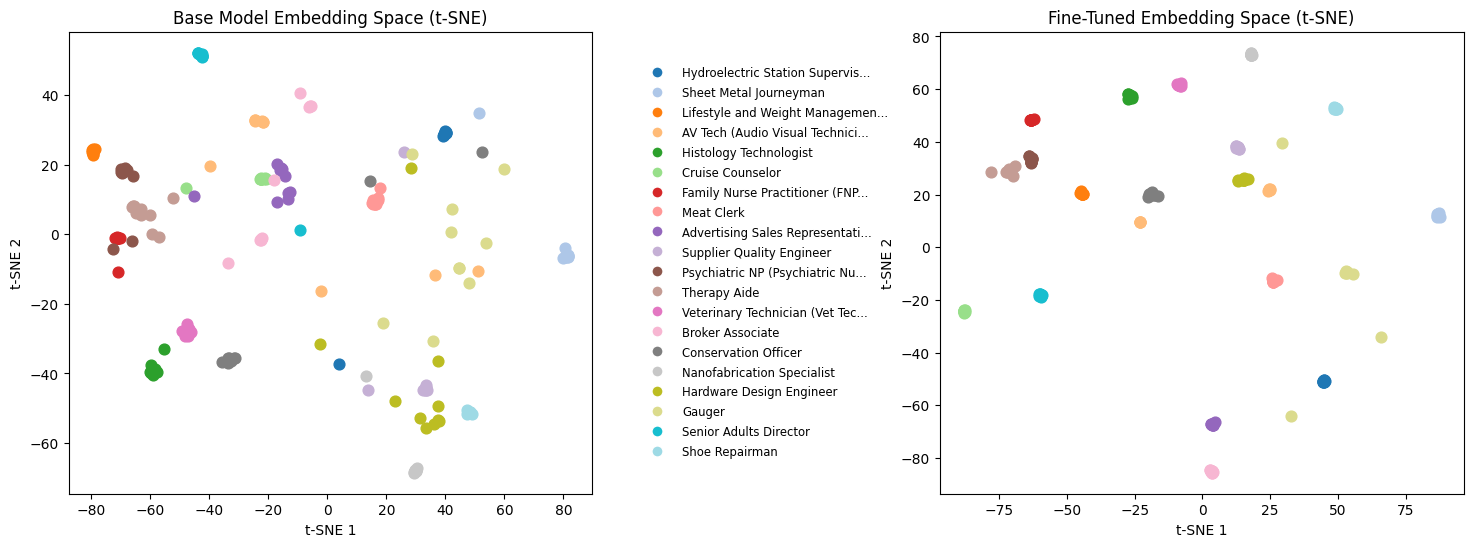

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# --- Data Subset and Embedding Extraction ---
subset_size = 20
random_seed_title_subset = np.random.choice(test_df['seed_title'].unique(), subset_size, replace=False)
seed_title_mask = test_df['seed_title'].isin(random_seed_title_subset)

test_df_subset = test_df[seed_title_mask]

base_model_embeddings_subset_2d = base_model_embeddings_2d[seed_title_mask, :]
fine_tuned_embeddings_subset_2d = fine_tuned_embeddings_2d[seed_title_mask, :]

# --- Prepare Color Mapping using 'tab20' for up to 20 classes ---
unique_labels = test_df_subset['seed_title'].unique()
colors = plt.cm.get_cmap('tab20', len(unique_labels))
color_map = {label: colors(i) for i, label in enumerate(unique_labels)}

# Truncate long label names for the legend.
max_label_len = 30
short_labels = {
    label: (label if len(label) <= max_label_len else label[:max_label_len] + '...')
    # label: label
    for label in unique_labels
}

# --- Create Figure with GridSpec Layout ---
# Three columns: left for base model plot, middle for legend, right for fine-tuned plot.
fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 0.35, 1], wspace=0.2)

ax_left = fig.add_subplot(gs[0])
ax_right = fig.add_subplot(gs[2])
ax_legend = fig.add_subplot(gs[1])

# --- Plot Base Model Embedding Space ---
for label in unique_labels:
    idx = test_df_subset['seed_title'] == label
    ax_left.scatter(base_model_embeddings_subset_2d[idx, 0], base_model_embeddings_subset_2d[idx, 1],
                    color=color_map[label], s=60)
ax_left.set_title("Base Model Embedding Space (t-SNE)")
ax_left.set_xlabel("t-SNE 1")
ax_left.set_ylabel("t-SNE 2")

# --- Plot Fine-Tuned Embedding Space ---
for label in unique_labels:
    idx = test_df_subset['seed_title'] == label
    ax_right.scatter(fine_tuned_embeddings_subset_2d[idx, 0], fine_tuned_embeddings_subset_2d[idx, 1],
                     color=color_map[label], s=60)
ax_right.set_title("Fine-Tuned Embedding Space (t-SNE)")
ax_right.set_xlabel("t-SNE 1")
ax_right.set_ylabel("t-SNE 2")

# --- Create a Vertical Legend in the Middle Column ---
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=color_map[label], markersize=8,
               label=short_labels[label])
    for label in unique_labels
]
ax_legend.axis('off')  # Hide the axis for the legend.
legend = ax_legend.legend(handles=handles, loc='center', frameon=False, ncol=1)
plt.setp(legend.get_texts(), fontsize='small')  # Adjust font size if needed

plt.tight_layout()
plt.show()

# EmbeddingSimilarityEvaluator

In [11]:
import pandas as pd
import random
from sentence_transformers import SentenceTransformer
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator

# ===== 1. 读取数据 =====
df = test_df.copy()

# ===== 2. helper functions =====
def get_major_group(code: str):
    if pd.isna(code):
        return None
    return str(code).split("-")[0]

def compute_score(code1: str, code2: str):
    if code1 == code2:
        return 1.0
    elif get_major_group(code1) == get_major_group(code2):
        return 0.7
    else:
        return 0.0

# ===== 3. 随机采样 =====
n = 300

sample1 = df.sample(n=n, random_state=42).reset_index(drop=True)
sample2 = df.sample(n=n, random_state=99).reset_index(drop=True)

sentences1 = sample1["jittered_title"].tolist()
sentences2 = sample2["seed_title"].tolist()

codes1 = sample1["onet_code"].tolist()
codes2 = sample2["onet_code"].tolist()

# ===== 4. 计算 score =====
scores = [compute_score(c1, c2) for c1, c2 in zip(codes1, codes2)]



# ===== 6. evaluator =====
evaluator = EmbeddingSimilarityEvaluator(
    sentences1=sentences1,
    sentences2=sentences2,
    scores=scores,
    main_similarity="cosine",
    name="onet-hierarchy-random-eval"
)

# ===== 8. 运行 =====
base_model_result = evaluator(base_model)
fine_tuned_model_result = evaluator(fine_tuned_model)

print("Evaluation score for base model", base_model_result)
print("Evaluation score for fine-tuned model:", fine_tuned_model_result)

Evaluation score for base model {'onet-hierarchy-random-eval_pearson_cosine': 0.19352431518708912, 'onet-hierarchy-random-eval_spearman_cosine': 0.14891362902608288}
Evaluation score for fine-tuned model: {'onet-hierarchy-random-eval_pearson_cosine': 0.2032602223835912, 'onet-hierarchy-random-eval_spearman_cosine': 0.1559056607970113}


In [17]:
import pandas as pd

# If evaluator(base_model) and evaluator(fine_tuned_model) return dictionaries with metric names as keys:
if isinstance(base_model_result, dict) and isinstance(fine_tuned_model_result, dict):
    metrics = list(base_model_result.keys())
    results_df = pd.DataFrame(
        {
            "Base Model": [base_model_result[m] for m in metrics],
            "Fine-tuned Model": [fine_tuned_model_result[m] for m in metrics]
        },
        index=metrics
    )
else:
    # If only single scores are returned, use a generic metric name
    results_df = pd.DataFrame(
        {
            "Base Model": [base_model_result],
            "Fine-tuned Model": [fine_tuned_model_result]
        },
        index=["Evaluation Score"]
    )

print(results_df)

                                           Base Model  Fine-tuned Model
seed_to_jittered_eval_cosine_accuracy@1      0.949657          0.985126
seed_to_jittered_eval_cosine_accuracy@5      0.995423          0.998856
seed_to_jittered_eval_cosine_accuracy@10     0.997712          1.000000
seed_to_jittered_eval_cosine_precision@1     0.949657          0.985126
seed_to_jittered_eval_cosine_precision@5     0.901144          0.969108
seed_to_jittered_eval_cosine_precision@10    0.789931          0.913043
seed_to_jittered_eval_cosine_recall@1        0.094864          0.098411
seed_to_jittered_eval_cosine_recall@5        0.450235          0.484045
seed_to_jittered_eval_cosine_recall@10       0.789461          0.912128
seed_to_jittered_eval_cosine_ndcg@10         0.833112          0.934161
seed_to_jittered_eval_cosine_mrr@10          0.970013          0.991964
seed_to_jittered_eval_cosine_map@100         0.837459          0.945266


# InformationRetrievalEvaluator

In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sentence_transformers.evaluation import InformationRetrievalEvaluator

def build_ir_seed_to_jittered(df: pd.DataFrame):
    df = df.dropna(subset=["seed_title", "jittered_title", "onet_code"]).copy()

    df["seed_title"] = df["seed_title"].astype(str).str.strip()
    df["jittered_title"] = df["jittered_title"].astype(str).str.strip()
    df["onet_code"] = df["onet_code"].astype(str).str.strip()

    # -----------------------------
    # 1. corpus = jittered titles
    # -----------------------------
    corpus = {}
    code_to_doc_ids = {}

    for i, row in df.reset_index(drop=True).iterrows():
        doc_id = f"d{i}"
        jittered = row["jittered_title"]
        code = row["onet_code"]

        corpus[doc_id] = jittered
        code_to_doc_ids.setdefault(code, set()).add(doc_id)

    # -----------------------------
    # 2. queries = unique seed titles
    # -----------------------------
    unique_seeds = df[["seed_title", "onet_code"]].drop_duplicates().reset_index(drop=True)

    queries = {}
    relevant_docs = {}

    for i, row in unique_seeds.iterrows():
        qid = f"q{i}"
        seed = row["seed_title"]
        code = row["onet_code"]

        queries[qid] = seed
        relevant_docs[qid] = code_to_doc_ids.get(code, set())

    return queries, corpus, relevant_docs


# ===== 使用 =====
df = test_df.copy()

queries, corpus, relevant_docs = build_ir_seed_to_jittered(df)

print("Num queries:", len(queries))
print("Num corpus docs:", len(corpus))


# ===== evaluator =====
evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    accuracy_at_k=[1, 5, 10],
    mrr_at_k=[10],
    ndcg_at_k=[10],
    precision_recall_at_k=[1, 5, 10],
    show_progress_bar=True,
    name="seed_to_jittered_eval"
)

# ===== 运行 =====
base_model_result = evaluator(base_model)
fine_tuned_model_result = evaluator(fine_tuned_model)


Num queries: 874
Num corpus docs: 8739


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/274 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:09<00:00,  9.09s/it]


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/274 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:04<00:00,  4.89s/it]

Evaluation score for base model: {'seed_to_jittered_eval_cosine_accuracy@1': 0.9496567505720824, 'seed_to_jittered_eval_cosine_accuracy@5': 0.9954233409610984, 'seed_to_jittered_eval_cosine_accuracy@10': 0.9977116704805492, 'seed_to_jittered_eval_cosine_precision@1': 0.9496567505720824, 'seed_to_jittered_eval_cosine_precision@5': 0.9011441647597256, 'seed_to_jittered_eval_cosine_precision@10': 0.7899313501144166, 'seed_to_jittered_eval_cosine_recall@1': 0.09486397152301045, 'seed_to_jittered_eval_cosine_recall@5': 0.45023518942283247, 'seed_to_jittered_eval_cosine_recall@10': 0.7894609712687517, 'seed_to_jittered_eval_cosine_ndcg@10': 0.8331123912948406, 'seed_to_jittered_eval_cosine_mrr@10': 0.9700133485888638, 'seed_to_jittered_eval_cosine_map@100': 0.8374588895486024}
Evaluation score for fine-tuned model: {'seed_to_jittered_eval_cosine_accuracy@1': 0.9851258581235698, 'seed_to_jittered_eval_cosine_accuracy@5': 0.9988558352402745, 'seed_to_jittered_eval_cosine_accuracy@10': 1.0, 'se

In [15]:

import pandas as pd

# Create results dictionary
results_keys = list(base_model_result.keys())
results = {"Model": ["Base Model", "Fine-tuned Model"]}
for k in results_keys:
    results[k] = [base_model_result.get(k, None), fine_tuned_model_result.get(k, None)]

results_df = pd.DataFrame(results)
display(results_df)

,Model,seed_to_jittered_eval_cosine_accuracy@1,seed_to_jittered_eval_cosine_accuracy@5,seed_to_jittered_eval_cosine_accuracy@10,seed_to_jittered_eval_cosine_precision@1,seed_to_jittered_eval_cosine_precision@5,seed_to_jittered_eval_cosine_precision@10,seed_to_jittered_eval_cosine_recall@1,seed_to_jittered_eval_cosine_recall@5,seed_to_jittered_eval_cosine_recall@10,seed_to_jittered_eval_cosine_ndcg@10,seed_to_jittered_eval_cosine_mrr@10,seed_to_jittered_eval_cosine_map@100
0,Base Model,0.949657,0.995423,0.997712,0.949657,0.901144,0.789931,0.094864,0.450235,0.789461,0.833112,0.970013,0.837459
1,Fine-tuned Model,0.985126,0.998856,1.000000,0.985126,0.969108,0.913043,0.098411,0.484045,0.912128,0.934161,0.991964,0.945266
